<a href="https://colab.research.google.com/github/amitbhaskar112/CodeAlpha_UnemploymentAnalysis/blob/main/Unemployment_Analysis_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q kaggle

In [4]:
from google.colab import files
files.upload()

Saving kaggle (3).json to kaggle (3) (1).json


{'kaggle (3) (1).json': b'{"username":"jatins4567890","key":"590937a6c98d2f7560cfaede977c19ca"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp 'kaggle (3).json' ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
! kaggle.com/datasets//https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india/data

/bin/bash: line 1: kaggle.com/datasets//https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india/data: No such file or directory


In [7]:
import os
import zipfile

# 1. Naya Dataset Download karein
!kaggle datasets download -d gokulrajkmv/unemployment-in-india --force

# 2. Kaggle dataset download ke baad zip file ka naam dataset slug ke exact name jaisa hota hai
zip_file_name = "unemployment-in-india.zip"

# 3. Destination folder path set karein
destination_dir = "datasets/gokulrajkmv/unemployment-in-india"
os.makedirs(destination_dir, exist_ok=True)

# 4. Zip file extract karein
with zipfile.ZipFile(zip_file_name, "r") as zip_ref:
  zip_ref.extractall(destination_dir)

print(f"All files extracted to: {destination_dir}")
print("Extracted files:")
for root, dirs, files in os.walk(destination_dir):
  for name in files:
    print(os.path.join(root, name))

Dataset URL: https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india
License(s): other
100% 16.0k/16.0k [00:00<00:00, 26.2MB/s]

All files extracted to: datasets/gokulrajkmv/unemployment-in-india
Extracted files:
datasets/gokulrajkmv/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv
datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv


In [8]:
import pandas as pd


csv_file_path = 'datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv'


df = pd.read_csv(csv_file_path)


print(df.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [9]:
import pandas as pd

csv_file_path = 'datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv'
df = pd.read_csv(csv_file_path)

df.info()
df.describe()
df[' Estimated Unemployment Rate (%)'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


,count
Estimated Unemployment Rate (%),
0.00,11
3.31,4
12.50,3
3.57,3
5.45,3
...,...
9.47,1
12.25,1
10.45,1


Accuracy: 88.51%
Classification Report:
              precision    recall  f1-score   support

       Rural       0.92      0.86      0.89        78
       Urban       0.85      0.91      0.88        70

    accuracy                           0.89       148
   macro avg       0.89      0.89      0.89       148
weighted avg       0.89      0.89      0.89       148



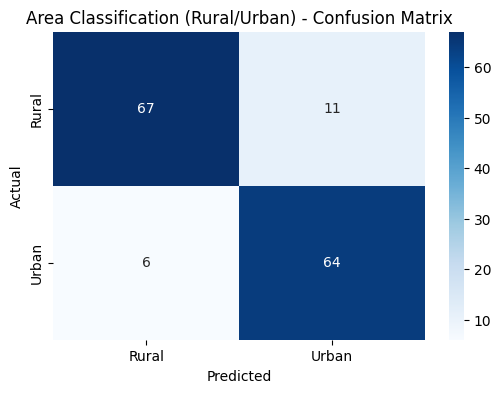

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import pandas as pd

# The 'df' DataFrame containing unemployment data is already loaded in previous cells.

# 1. Handle missing values in relevant columns
# Drop rows where any of the selected features or the target are NaN
df_cleaned = df.dropna(subset=[" Estimated Unemployment Rate (%)", " Estimated Employed", " Estimated Labour Participation Rate (%)", "Area"])

# 2. Define Features (X) and Target (y) using the unemployment dataset
X = df_cleaned[[" Estimated Unemployment Rate (%)", " Estimated Employed", " Estimated Labour Participation Rate (%)"]]
y = df_cleaned["Area"]  # Target column: Classify 'Area' (Rural/Urban)

# 3. Split data into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Select and train a Classification Model (Random Forest)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 5. Make Predictions on the testing data
y_pred = model.predict(X_test)

# 6. Evaluate Model Performance
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 7. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Area Classification (Rural/Urban) - Confusion Matrix")
plt.show()

In [11]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Dataset Load Karein (File path ki jagah 'xyz' use kiya hai)
file_path = "datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv"  # Apni CSV file ka path yahan badlein (e.g., 'xyz.csv')
df = pd.read_csv(file_path)

# 2. Data Cleaning
# Column names se extra spaces hatana
df.columns = df.columns.str.strip()

# Missing values waali rows hatana
df = df.dropna()

# Date column ko datetime format mein badalna
df["Date"] = pd.to_datetime(df["Date"].str.strip(), format="%d-%m-%Y")

# 3. Feature Engineering
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

# Categorical columns ko One-Hot Encode karna
categorical_cols = [c for c in ["Region", "Area", "Frequency"] if c in df.columns]
df_encoded = pd.get_dummies(
    df, columns=categorical_cols, drop_first=True, dtype=int
)

# 4. Target variable (y) aur Features (X) define karna
target = "Estimated Unemployment Rate (%)"
X = df_encoded.drop(columns=["Date", target])
y = df_encoded[target]

# 5. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Random Forest Model Train Karna
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 7. Model Evaluation
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Model Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

--- Model Metrics ---
Mean Absolute Error (MAE): 3.78
Root Mean Squared Error (RMSE): 6.66
R² Score: 0.69


In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# The 'df' DataFrame containing unemployment data is already loaded in previous cells.

# 1. Handle missing values in relevant columns
# Drop rows where any of the selected features or the target are NaN
df_cleaned = df.dropna(subset=["Estimated Unemployment Rate (%)", "Estimated Employed", "Estimated Labour Participation Rate (%)", "Area"])

# 2. Define Features (X) and Target (y) using the unemployment dataset
X = df_cleaned[["Estimated Unemployment Rate (%)", "Estimated Employed", "Estimated Labour Participation Rate (%)"]]
y = df_cleaned["Area"]  # Target column: Classify 'Area' (Rural/Urban)

# 3. Define the Classification Model
model = RandomForestClassifier(random_state=42)

# 4. Set up Stratified K-Fold Cross-Validation (5 splits)
# Stratified ensures that each fold maintains the same proportion of target classes as the overall dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Run Cross-validation
scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

# 6. Print Cross-validation Results
print("Accuracy for each fold:")
for i, score in enumerate(scores, 1):
    print(f"Fold {i}: {score * 100:.2f}%")

print("\n--- Summary ---")
print(f"Mean Accuracy: {scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {scores.std() * 100:.2f}%")

Accuracy for each fold:
Fold 1: 81.08%
Fold 2: 85.81%
Fold 3: 84.46%
Fold 4: 82.43%
Fold 5: 81.76%

--- Summary ---
Mean Accuracy: 83.11%
Standard Deviation: 1.76%
